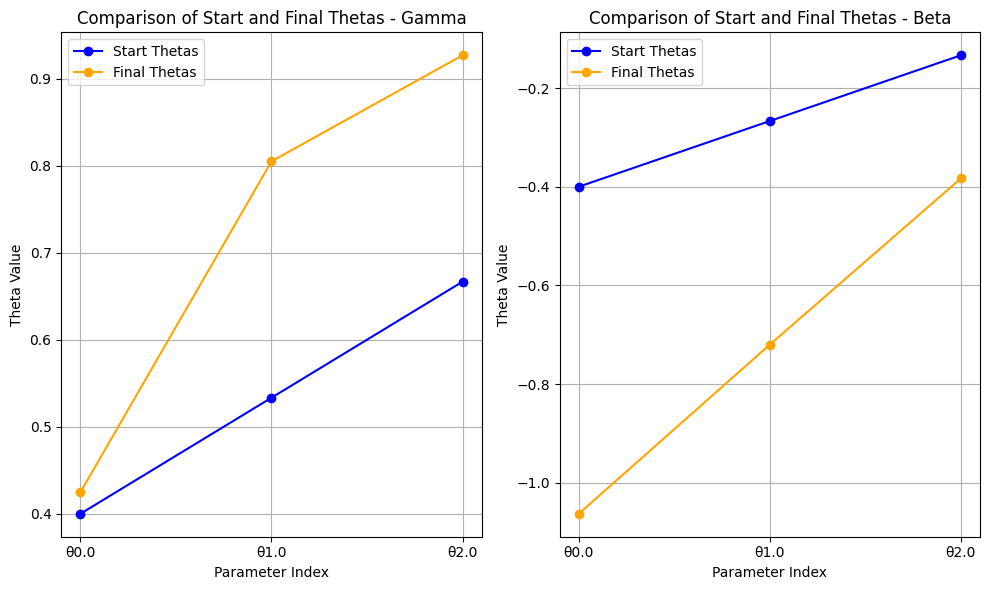

In [5]:
import numpy as np
import matplotlib.pyplot as plt
start_thetas = np.array([
        0.4,
        -0.4000000000000001,
        0.5333333333333333,
        -0.2666666666666667,
        0.6666666666666667,
        -0.13333333333333336
      ])
final_thetas= np.array([
        0.4247528719776978,
        -1.063090474425143,
        0.8048734909537345,
        -0.7200651143926983,
        0.9267352398351238,
        -0.38301624136668316
      ])

# 짝수와 홀수번째 인덱스를 구분해서 시각화
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
x = np.arange(len(start_thetas)/2)
ax[0].plot(x, start_thetas[::2], marker='o', label='Start Thetas', color='blue')
ax[0].plot(x, final_thetas[::2], marker='o', label='Final Thetas', color='orange')
ax[0].set_xticks(x)
ax[0].set_xticklabels([f'θ{i}' for i in x])
ax[0].set_xlabel('Parameter Index')
ax[0].set_ylabel('Theta Value')
ax[0].set_title('Comparison of Start and Final Thetas - Gamma')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x, start_thetas[1::2], marker='o', label='Start Thetas', color='blue')
ax[1].plot(x, final_thetas[1::2], marker='o', label='Final Thetas', color='orange')
ax[1].set_xticks(x)
ax[1].set_xticklabels([f'θ{i}' for i in x])
ax[1].set_xlabel('Parameter Index')
ax[1].set_ylabel('Theta Value')
ax[1].set_title('Comparison of Start and Final Thetas - Beta')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import math
import time
import itertools
from typing import List, Tuple

import torch


# =========================
# Utility
# =========================

def sync_if_needed(device: torch.device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def reset_cuda_peak_memory(device: torch.device):
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)


def get_cuda_peak_memory_mb(device: torch.device) -> float:
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    return float("nan")


# =========================
# Construct commuting dense involutions A_j
# A_j = U diag(signs_j) U^T
# so [A_i, A_j] = 0 and A_j^2 = I
# =========================

@torch.no_grad()
def make_commuting_involutions(
    dim: int,
    m: int,
    device: torch.device,
    dtype: torch.dtype = torch.float32,
    seed: int = 0,
) -> List[torch.Tensor]:
    """
    Returns dense commuting matrices A_j of shape [dim, dim]
    with A_j^2 = I and [A_i, A_j] = 0.
    """
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)

    # Random orthogonal matrix U (CPU for reproducibility, then move)
    X = torch.randn(dim, dim, generator=g, dtype=torch.float64)
    Q, _ = torch.linalg.qr(X)
    U = Q.to(dtype=dtype, device=device)

    A_list = []
    for _ in range(m):
        signs = torch.randint(
            low=0, high=2, size=(dim,), generator=g, dtype=torch.int64
        )
        signs = 2 * signs - 1  # {-1, +1}
        D = torch.diag(signs.to(dtype=dtype, device=device))
        A = U @ D @ U.T
        A_list.append(A.contiguous())

    return A_list


# =========================
# Offline compile for Version B
# S_S = product_{j in S} A_j
# alpha_S(theta) = prod_{j notin S} cos(theta_j) * prod_{j in S} sin(theta_j)
# Since all A_j commute and A_j^2 = I:
# prod_j (cos θ_j I + sin θ_j A_j) = Σ_S α_S(theta) S_S
# =========================

@torch.no_grad()
def compile_subset_basis(
    A_list: List[torch.Tensor],
) -> Tuple[List[Tuple[int, ...]], torch.Tensor]:
    """
    Precompute all subset basis matrices S_S.
    Returns:
      subsets: list of tuples of indices
      basis: tensor [K, dim, dim], K = 2^m
    """
    m = len(A_list)
    device = A_list[0].device
    dtype = A_list[0].dtype
    dim = A_list[0].shape[0]

    subsets = []
    basis = []

    I = torch.eye(dim, device=device, dtype=dtype)

    for mask in range(1 << m):
        idxs = tuple(j for j in range(m) if (mask >> j) & 1)
        subsets.append(idxs)

        S = I
        for j in idxs:
            S = S @ A_list[j]
        basis.append(S)

    basis = torch.stack(basis, dim=0).contiguous()  # [K, dim, dim]
    return subsets, basis


def compute_subset_coeffs(
    theta: torch.Tensor,
    subsets: List[Tuple[int, ...]],
) -> torch.Tensor:
    """
    theta: [m], requires_grad=True
    returns alpha: [K]
    """
    cos_t = torch.cos(theta)
    sin_t = torch.sin(theta)

    coeffs = []
    m = theta.numel()
    all_idx = set(range(m))

    for idxs in subsets:
        idxs_set = set(idxs)
        not_idxs = all_idx - idxs_set

        if len(idxs) == 0:
            s_part = theta.new_tensor(1.0)
        else:
            s_part = torch.prod(sin_t[list(idxs)])

        if len(not_idxs) == 0:
            c_part = theta.new_tensor(1.0)
        else:
            c_part = torch.prod(cos_t[list(not_idxs)])

        coeffs.append(c_part * s_part)

    return torch.stack(coeffs, dim=0)  # [K]


# =========================
# Version A: direct product
# =========================

def forward_version_a(
    theta: torch.Tensor,
    A_list: List[torch.Tensor],
    x: torch.Tensor,
) -> torch.Tensor:
    """
    theta: [m]
    x: [dim, batch]
    """
    device = x.device
    dtype = x.dtype
    dim = x.shape[0]

    B = torch.eye(dim, device=device, dtype=dtype)
    for j, A in enumerate(A_list):
        Mj = torch.cos(theta[j]) * torch.eye(dim, device=device, dtype=dtype) \
             + torch.sin(theta[j]) * A
        B = B @ Mj
    y = B @ x
    return y


# =========================
# Version B: compiled subset expansion
# =========================

def forward_version_b(
    theta: torch.Tensor,
    subsets: List[Tuple[int, ...]],
    basis: torch.Tensor,
    x: torch.Tensor,
) -> torch.Tensor:
    """
    basis: [K, dim, dim]
    x: [dim, batch]
    """
    alpha = compute_subset_coeffs(theta, subsets)  # [K]

    # B = Σ_k alpha_k S_k
    # einsum: [K] x [K, d, d] -> [d, d]
    B = torch.einsum("k,kij->ij", alpha, basis)
    y = B @ x
    return y


# =========================
# Benchmark helpers
# =========================

def run_once_and_measure(
    fn,
    *args,
    warmup: int = 3,
    iters: int = 20,
    device: torch.device,
):
    # Warmup
    for _ in range(warmup):
        loss = fn(*args)
        loss.backward()
        for a in args:
            if isinstance(a, torch.Tensor) and a.requires_grad:
                a.grad = None
        sync_if_needed(device)

    # Timed
    reset_cuda_peak_memory(device)
    sync_if_needed(device)
    t0 = time.perf_counter()

    for _ in range(iters):
        loss = fn(*args)
        loss.backward()
        for a in args:
            if isinstance(a, torch.Tensor) and a.requires_grad:
                a.grad = None

    sync_if_needed(device)
    t1 = time.perf_counter()

    avg_ms = (t1 - t0) * 1000.0 / iters
    peak_mem_mb = get_cuda_peak_memory_mb(device)
    return avg_ms, peak_mem_mb


def make_loss_from_forward(forward_fn):
    def wrapped(*args):
        y = forward_fn(*args)
        return (y ** 2).mean()
    return wrapped


# =========================
# Main experiment
# =========================

def experiment(
    dim: int = 256,
    m: int = 6,
    batch: int = 32,
    device_str: str = "cuda",
    dtype: torch.dtype = torch.float32,
    seed: int = 0,
):
    device = torch.device(device_str if torch.cuda.is_available() or device_str == "cpu" else "cpu")
    print(f"device = {device}, dtype = {dtype}, dim = {dim}, m = {m}, batch = {batch}")

    # Build commuting operators
    A_list = make_commuting_involutions(dim, m, device=device, dtype=dtype, seed=seed)

    # Offline compile for B
    t_compile0 = time.perf_counter()
    subsets, basis = compile_subset_basis(A_list)
    sync_if_needed(device)
    t_compile1 = time.perf_counter()
    compile_ms = (t_compile1 - t_compile0) * 1000.0

    print(f"[offline compile B] subsets = {len(subsets)} = 2^{m}, compile_time = {compile_ms:.2f} ms")

    # Same theta/x for both
    theta_a = torch.randn(m, device=device, dtype=dtype, requires_grad=True)
    theta_b = theta_a.detach().clone().requires_grad_(True)
    x = torch.randn(dim, batch, device=device, dtype=dtype)

    # Correctness check
    with torch.enable_grad():
        y_a = forward_version_a(theta_a, A_list, x)
        y_b = forward_version_b(theta_b, subsets, basis, x)

    max_abs = (y_a - y_b).abs().max().item()
    rel = ((y_a - y_b).norm() / (y_a.norm() + 1e-12)).item()
    print(f"[correctness] max_abs = {max_abs:.3e}, rel = {rel:.3e}")

    # Benchmark forward+backward
    loss_a = make_loss_from_forward(forward_version_a)
    loss_b = make_loss_from_forward(forward_version_b)

    avg_ms_a, peak_mem_a = run_once_and_measure(
        loss_a, theta_a, A_list, x, device=device
    )
    avg_ms_b, peak_mem_b = run_once_and_measure(
        loss_b, theta_b, subsets, basis, x, device=device
    )

    print("\n=== Benchmark (forward + backward) ===")
    print(f"Version A: {avg_ms_a:.3f} ms/iter, peak CUDA mem = {peak_mem_a:.2f} MB")
    print(f"Version B: {avg_ms_b:.3f} ms/iter, peak CUDA mem = {peak_mem_b:.2f} MB")

    if math.isfinite(peak_mem_a) and math.isfinite(peak_mem_b):
        print(f"Speedup B/A = {avg_ms_a / avg_ms_b:.3f}x")
        print(f"Memory ratio B/A = {peak_mem_b / peak_mem_a:.3f}x")

    return {
        "device": str(device),
        "dim": dim,
        "m": m,
        "batch": batch,
        "compile_ms_B": compile_ms,
        "max_abs_error": max_abs,
        "rel_error": rel,
        "version_A_ms": avg_ms_a,
        "version_B_ms": avg_ms_b,
        "version_A_peak_mem_mb": peak_mem_a,
        "version_B_peak_mem_mb": peak_mem_b,
    }


if __name__ == "__main__":
    # 추천 시작점
    # m은 2^m basis가 필요하므로 처음엔 4~8 정도로 시작
    # dim은 128, 256, 512 정도로 비교
    stats = experiment(
        dim=256,
        m=10,
        batch=32,
        device_str="cuda",   # GPU 없으면 자동으로 cpu fallback
        dtype=torch.float32,
        seed=0,
    )
    print("\nStats:", stats)

device = cuda, dtype = torch.float32, dim = 256, m = 10, batch = 32
[offline compile B] subsets = 1024 = 2^10, compile_time = 70.94 ms
[correctness] max_abs = 3.755e-06, rel = 7.568e-07
